# Vacuum PMNS examples

This notebook gathers two examples from the `examples/` directory:

- `vacuum_pmns.py`: vacuum oscillation probabilities for an initial `nu_mu` beam.
- `vacuum_pmns_variable.py`: comparison between normal ordering and inverted ordering.

The notebook can be executed either from the repository root or from `notebooks/`.

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))

from nu_waves.models.mixing import Mixing
from nu_waves.models.spectrum import Spectrum
from nu_waves.hamiltonian import vacuum
from nu_waves.globals.backend import Backend
from nu_waves.propagation.oscillator import NeutrinoEvent, NeutrinoEventBatch, Oscillator
import nu_waves.utils.flavors as flavors
import nu_waves.utils.style


## Shared configuration

We initialize here the 3-flavor PMNS mixing setup and the mass spectrum used by both examples.

In [2]:
# import torch
# Backend.set_api(torch, device="mps")
# Backend.set_api(torch, device="cpu")

# import jax
# Backend.set_api(jax, device="mps")
# Backend.set_api(jax, device="cpu")

angles = {(1, 2): np.deg2rad(33.4), (1, 3): np.deg2rad(8.6), (2, 3): np.deg2rad(49)}
phases = {(1, 3): np.deg2rad(195)}
dm2 = {(2, 1): 7.42e-5, (3, 2): 0.0024428}

def build_vacuum_oscillator(dm2_override=None):
    dm2_local = dict(dm2)
    if dm2_override is not None:
        dm2_local.update(dm2_override)

    h = vacuum.Hamiltonian(
        mixing=Mixing(n_neutrinos=3, mixing_angles=angles, dirac_phases=phases),
        spectrum=Spectrum(n_neutrinos=3, m_lightest=0, dm2=dm2_local),
        antineutrino=False,
    )
    return Oscillator(hamiltonian=h)


## 1. Reproduction of `vacuum_pmns.py`

Compute the oscillation probabilities for an initial `nu_mu` beam over a 295 km baseline.

In [3]:
osc = build_vacuum_oscillator()

n_points = int(1e5)
E_min, E_max = 0.2, 3.0
Enu_list = np.linspace(E_min, E_max, n_points)

t0 = time.perf_counter()
P = osc.probability(
    L_km=295,
    E_GeV=Enu_list,
    flavor_emit=flavors.muon,
    flavor_det=[flavors.electron, flavors.muon, flavors.tau],
)
t1 = time.perf_counter()

print(f"Execution time: {t1 - t0:.3f} s")
print(f"Output shape: {P.shape}")


Execution time: 0.025 s
Output shape: (100000, 3)


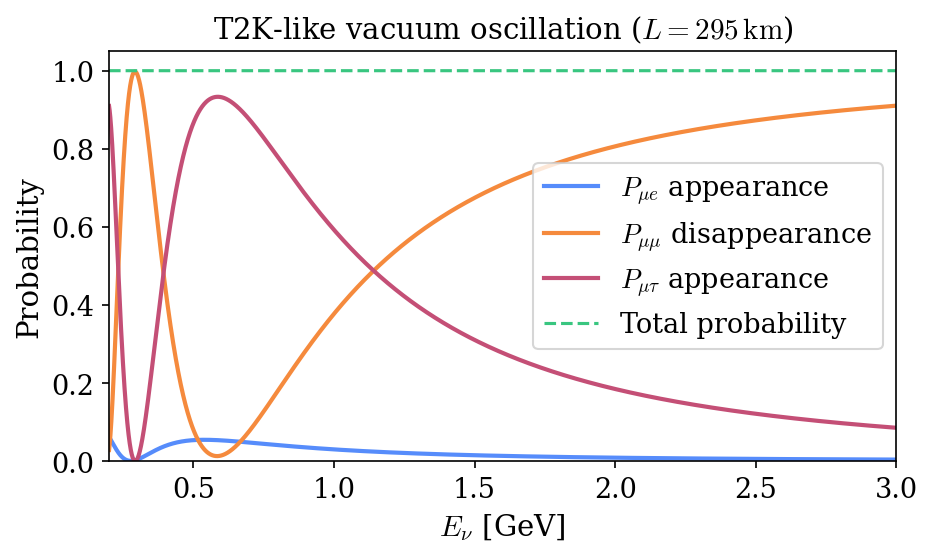

In [4]:
plt.figure(figsize=(6.5, 4.0))
plt.plot(Enu_list, P[:, flavors.electron], label=r"$P_{\mu e}$ appearance", lw=2)
plt.plot(Enu_list, P[:, flavors.muon], label=r"$P_{\mu\mu}$ disappearance", lw=2)
plt.plot(Enu_list, P[:, flavors.tau], label=r"$P_{\mu\tau}$ appearance", lw=2)
plt.plot(Enu_list, P.sum(axis=1), "--", label="Total probability", lw=1.5)
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel("Probability")
plt.title(r"T2K-like vacuum oscillation ($L=295\,\mathrm{km}$)")
plt.xlim(E_min, E_max)
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


## 2. Reproduction of `vacuum_pmns_variable.py`

Here we compare `P(nu_mu -> nu_e)` for two spectrum choices: normal ordering and inverted ordering.

In [5]:
osc_no = build_vacuum_oscillator()
osc_io = build_vacuum_oscillator(dm2_override={(3, 2): -0.0024428})

E_min, E_max = 0.2, 3.0
Enu_list = np.linspace(E_min, E_max, 200)

P_no = osc_no.probability(
    L_km=295,
    E_GeV=Enu_list,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)

P_io = osc_io.probability(
    L_km=295,
    E_GeV=Enu_list,
    flavor_emit=flavors.muon,
    flavor_det=flavors.electron,
)


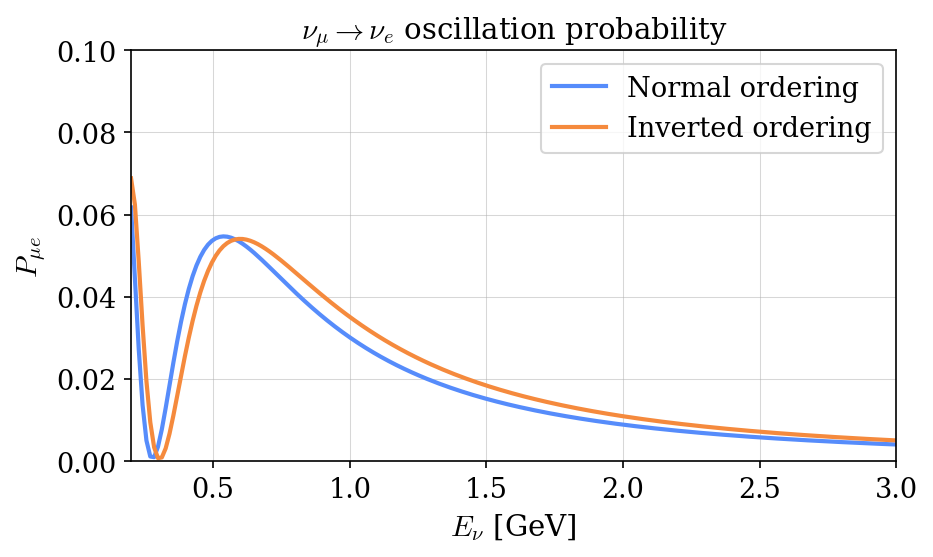

In [6]:
plt.figure(figsize=(6.5, 4.0))
plt.plot(Enu_list, P_no, label="Normal ordering", lw=2)
plt.plot(Enu_list, P_io, label="Inverted ordering", lw=2)
plt.xlabel(r"$E_\nu$ [GeV]")
plt.ylabel(r"$P_{\mu e}$")
plt.title(r"$\nu_\mu \rightarrow \nu_e$ oscillation probability")
plt.xlim(E_min, E_max)
plt.ylim(0, 0.1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Event spectra for a T2K-like beam


We build here a `nu_mu` Monte Carlo sample using a toy T2K-like beam spectrum, peaked around `0.6 GeV` with a broader high-energy tail.

The same `E_nu_true` events are then propagated into four channel/sign samples:

- disappearance `nu_mu -> nu_mu`
- appearance `nu_mu -> nu_e`
- disappearance `anti-nu_mu -> anti-nu_mu`
- appearance `anti-nu_mu -> anti-nu_e`

The histograms are drawn as a function of `E_nu_true`, with event-by-event oscillation probabilities used as weights. All channels are computed in a single call to `osc_events.probability`.

In [7]:
osc_events = build_vacuum_oscillator()

rng = np.random.default_rng(42)

n_events = 60000
E_min, E_max = 0.2, 3.0
beam_grid = np.linspace(E_min, E_max, 1200)

# Toy T2K-like spectrum: narrow peak around 0.6 GeV and a broader secondary tail.
beam_flux = (
    0.85 * np.exp(-0.5 * ((beam_grid - 0.62) / 0.16) ** 2)
    + 0.15 * np.exp(-0.5 * ((beam_grid - 1.15) / 0.35) ** 2)
)
beam_pdf = beam_flux / beam_flux.sum()

E_nu_true = rng.choice(beam_grid, size=n_events, p=beam_pdf)
L_true_km = np.full(n_events, 295.0)
hist_bins = np.linspace(E_min, E_max, 29)

event_batch_all = NeutrinoEventBatch(
    L_km=np.tile(L_true_km, 4),
    E_GeV=np.tile(E_nu_true, 4),
    flavor_emit=np.full(4 * n_events, flavors.muon, dtype=int),
    flavor_det=np.concatenate([
        np.full(n_events, flavors.muon, dtype=int),
        np.full(n_events, flavors.electron, dtype=int),
        np.full(n_events, flavors.muon, dtype=int),
        np.full(n_events, flavors.electron, dtype=int),
    ]),
    isAntiNu=np.concatenate([
        np.full(2 * n_events, False, dtype=bool),
        np.full(2 * n_events, True, dtype=bool),
    ]),
)

P_all = osc_events.probability(event_batch_all)
P_numu_to_numu = P_all[:n_events]
P_numu_to_nue = P_all[n_events:2 * n_events]
P_antinumu_to_antinumu = P_all[2 * n_events:3 * n_events]
P_antinumu_to_antinue = P_all[3 * n_events:]

print(f"Number of generated events: {n_events}")
print(f"Mean neutrino survival weight: {P_numu_to_numu.mean():.3f}")
print(f"Mean neutrino appearance weight: {P_numu_to_nue.mean():.3f}")
print(f"Mean antineutrino survival weight: {P_antinumu_to_antinumu.mean():.3f}")
print(f"Mean antineutrino appearance weight: {P_antinumu_to_antinue.mean():.3f}")


Number of generated events: 60000
Mean neutrino survival weight: 0.245
Mean neutrino appearance weight: 0.041
Mean antineutrino survival weight: 0.245
Mean antineutrino appearance weight: 0.036


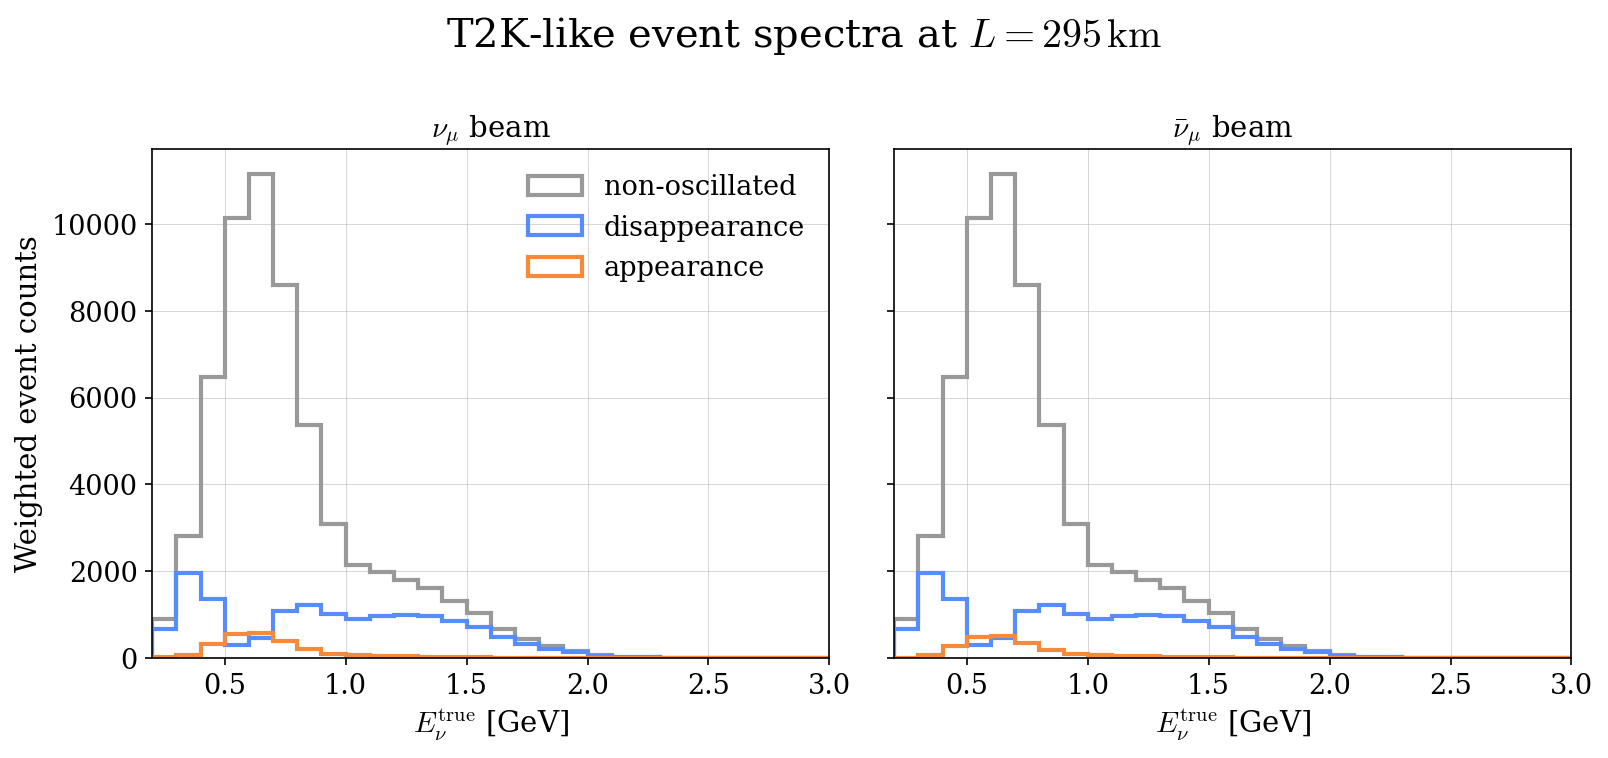

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(11.0, 5.2), sharex=True, sharey=True)

for ax, survival, appearance, title in [
    (axs[0], P_numu_to_numu, P_numu_to_nue, r"$\nu_\mu$ beam"),
    (axs[1], P_antinumu_to_antinumu, P_antinumu_to_antinue, r"$\bar{\nu}_\mu$ beam"),
]:
    ax.hist(E_nu_true, bins=hist_bins, histtype="step", linewidth=2.0, color="0.6", label="non-oscillated")
    ax.hist(E_nu_true, bins=hist_bins, weights=survival, histtype="step", linewidth=2.0, label="disappearance")
    ax.hist(E_nu_true, bins=hist_bins, weights=appearance, histtype="step", linewidth=2.0, label="appearance")
    ax.set_title(title)
    ax.set_xlabel(r"$E_{\nu}^{\mathrm{true}}$ [GeV]")
    ax.set_xlim(E_min, E_max)
    ax.grid(True)

axs[0].set_ylabel("Weighted event counts")
axs[0].legend(frameon=False)
fig.suptitle(r"T2K-like event spectra at $L=295\,\mathrm{km}$")
fig.tight_layout()
plt.show()


## 4. Reproduction of `vacuum_backend.py`

This section reproduces the backend-oriented vacuum checks:

- output shape in full probability mode
- high-energy identity limit
- probability conservation
- optional comparison with a Torch backend if available


In [9]:
backend_osc = build_vacuum_oscillator()

print("Testing shape of Oscillator.probability")
P_shape = backend_osc.probability(L_km=295, E_GeV=np.linspace(0.2, 2.0, 5))
assert P_shape.shape == (5, 3, 3)

print("Testing high-energy identity limit")
P_hi = backend_osc.probability(L_km=295, E_GeV=1e6)
np.testing.assert_allclose(P_hi, np.eye(3), atol=1e-12)

print("Testing probability conservation")
P_full = backend_osc.probability(
    L_km=295,
    E_GeV=np.linspace(0.2, 2.0, 50),
    flavor_emit=None,
    flavor_det=None,
)
np.testing.assert_allclose(P_full.sum(axis=-2), 1.0, atol=1e-12)

print("NumPy backend checks passed.")


Testing shape of Oscillator.probability
Testing high-energy identity limit
Testing probability conservation
NumPy backend checks passed.


[Torch] Using device: cpu


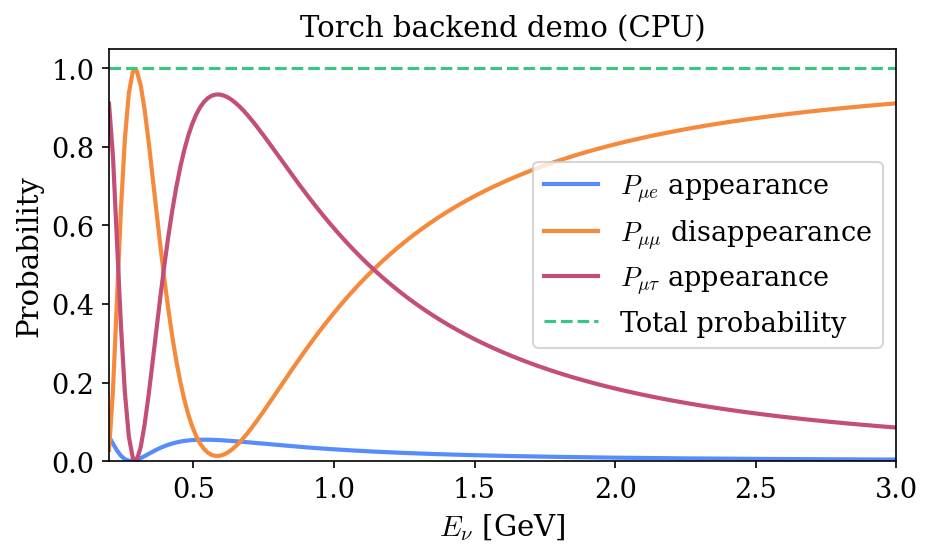

In [10]:
try:
    import torch
except ImportError:
    torch = None

if torch is None:
    print("Torch is not available. Skipping Torch backend demo.")
else:
    Backend.set_api(torch, device="cpu")
    osc_torch = build_vacuum_oscillator()

    E_hi = np.array([1e6])
    P_torch_hi = osc_torch.probability(
        L_km=295,
        E_GeV=E_hi,
        flavor_emit=None,
        flavor_det=None,
    )
    np.testing.assert_allclose(P_hi, P_torch_hi, rtol=1e-4, atol=1e-5)

    E_backend = np.linspace(0.2, 2.0, 200)
    P_torch_full = osc_torch.probability(
        L_km=295,
        E_GeV=E_backend,
        flavor_emit=None,
        flavor_det=None,
    )
    np.testing.assert_allclose(P_torch_full.sum(axis=-2), 1.0, atol=2e-6)

    E_plot = np.linspace(0.2, 3.0, 200)
    P_torch_plot = osc_torch.probability(
        L_km=295,
        E_GeV=E_plot,
        flavor_emit=flavors.muon,
        flavor_det=[flavors.electron, flavors.muon, flavors.tau],
    )

    plt.figure(figsize=(6.5, 4.0))
    plt.plot(E_plot, P_torch_plot[:, flavors.electron], label=r"$P_{\mu e}$ appearance", lw=2)
    plt.plot(E_plot, P_torch_plot[:, flavors.muon], label=r"$P_{\mu\mu}$ disappearance", lw=2)
    plt.plot(E_plot, P_torch_plot[:, flavors.tau], label=r"$P_{\mu\tau}$ appearance", lw=2)
    plt.plot(E_plot, P_torch_plot.sum(axis=1), "--", label="Total probability", lw=1.5)
    plt.xlabel(r"$E_\nu$ [GeV]")
    plt.ylabel("Probability")
    plt.title("Torch backend demo (CPU)")
    plt.xlim(E_plot.min(), E_plot.max())
    plt.ylim(0, 1.05)
    plt.legend()
    plt.tight_layout()
    plt.show()

    Backend.set_api(np)


## 5. Reproduction of `vacuum_2d_pmns.py`

This section computes two vacuum oscillograms on a 2D grid in energy and baseline:

- `P(nu_mu -> nu_e)` appearance
- `P(nu_mu -> nu_mu)` disappearance


In [11]:
from matplotlib.colors import LogNorm

osc_2d = build_vacuum_oscillator()

nE = 400
nL = 400
E_vals = np.linspace(0.2, 5.0, nE)
L_vals = np.linspace(1000.0, 2000.0, nL)
E_grid, L_grid = np.meshgrid(E_vals, L_vals, indexing="xy")

L_flat = L_grid.ravel()
E_flat = E_grid.ravel()

t0 = time.perf_counter()
P_mue_2d = osc_2d.probability(L_km=L_flat, E_GeV=E_flat, flavor_emit=flavors.muon, flavor_det=flavors.electron)
P_mumu_2d = osc_2d.probability(L_km=L_flat, E_GeV=E_flat, flavor_emit=flavors.muon, flavor_det=flavors.muon)
t1 = time.perf_counter()
print(f"2D grid computation time: {t1 - t0:.3f} s")

P_mue_2d = P_mue_2d.reshape(nL, nE)
P_mumu_2d = P_mumu_2d.reshape(nL, nE)


2D grid computation time: 0.075 s


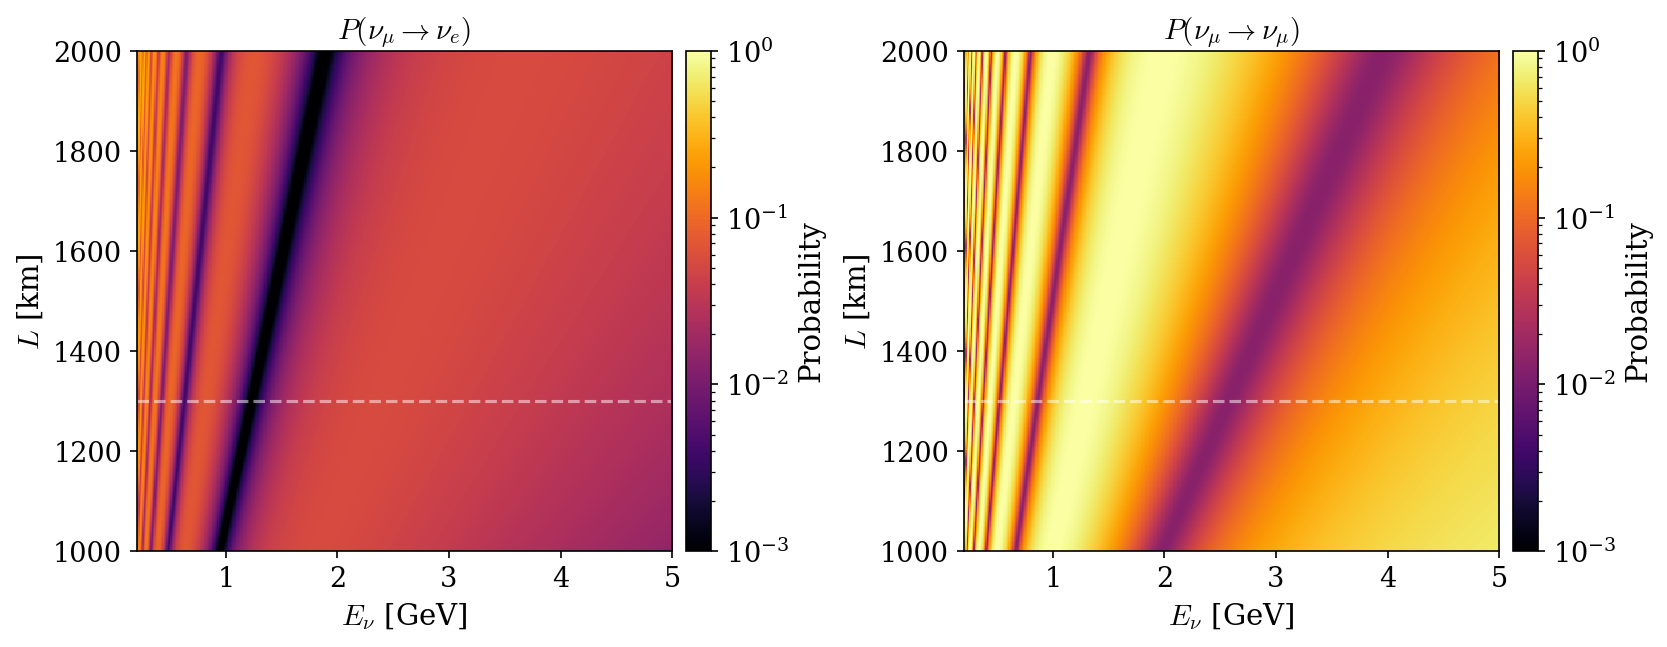

In [12]:
def plot_oscillogram(ax, E, L, P, title):
    im = ax.imshow(
        P + 1e-10,
        origin="lower",
        aspect="auto",
        extent=[E.min(), E.max(), L.min(), L.max()],
        norm=LogNorm(vmin=1e-3, vmax=1.0),
        interpolation="nearest",
        cmap="inferno",
    )
    ax.axhline(y=1300.0, color="white", linestyle="--", alpha=0.5)
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_ylabel(r"$L$ [km]")
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, pad=0.01)
    cbar.set_label("Probability")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
plot_oscillogram(axes[0], E_vals, L_vals, P_mue_2d,  r"$P(\nu_\mu\to\nu_e)$")
plot_oscillogram(axes[1], E_vals, L_vals, P_mumu_2d, r"$P(\nu_\mu\to\nu_\mu)$")
plt.show()
